In [ ]:
from pathlib import Path

import util
from util import workflow

browser = False
file = util.notebook_file() if util.is_notebook() else __file__
tag = util.file_tag(file)
root_path = Path("..")

In [ ]:
# # Build
# from automol.graph import enum

# import automech
# from automech.species import Species

# par_mech = workflow.read_parent_mechanism(root_path=root_path)
# mech = automech.from_smiles(spc_smis=["C1=CCCC1", "C12C(O2)CCC1"], src_mech=par_mech)
# #  - enumerate HO2 abstractions from *ene* and *1-2epoxy*
# mech = automech.enumerate_reactions(
#     mech,
#     enum.ReactionSmarts.abstraction,
#     rcts_=[["C1=CCCC1", "C12C(O2)CCC1"], "O[O]"],
#     spc_col_=Species.smiles,
#     src_mech=par_mech,
# )
# automech.display(mech)

In [ ]:
# # Write
# workflow.write(mech=mech, tag=tag, root_path=root_path, browser=browser)

In [ ]:
# # Read
# workflow.read(tag=tag, root_path=root_path)

In [ ]:
# # Simulate
# workflow.simulate(full_tag=f"full_{tag}_calc", root_path=root_path)
# workflow.simulate(full_tag=f"full_{tag}_control", root_path=root_path)

In [28]:
import automech
from mechdriver.subtasks import display, fs

chan = "2: 5"

# TRANSITION STATE
#   - Read in expanded mechanism
mech_path = util.p_.mechanism(tag, ext="json", path=util.p_.data(root_path))
mech = automech.io.read(mech_path)

#   - Display the reaction
automech.display_reactions(mech, chans=[chan])


*********
Reaction: C5H8O(825)rs + HO2(8) = S(1314)r1 + H2O2(10)
Translations:
  smiles:
    reactants = ['C1C[C@H]2[C@@H](C1)O2', '[O]O']
    products = ['C1C[C]2[C@@H](C1)O2', 'OO']
Rate parameters:
  This work:
    C5H8O(825)rs + HO2(8) = S(1314)r1 + H2O2(10)                 1.000      0.000      0.000


alt.Chart(...)

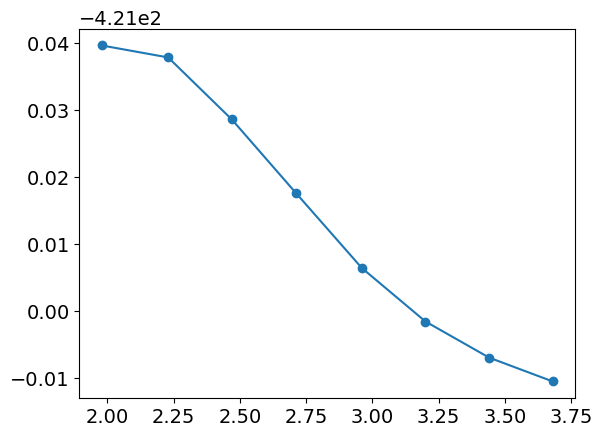

Coordinate 1.98 geometry: 


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Coordinate 2.96 geometry: 


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Coordinate 3.68 geometry: 


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [30]:
#   - Display the TS mode
calc_path = util.p_.calc(root_path, tag)
display("find_ts", chan, path=calc_path)

In [ ]:
# # REACTION RATE
# #   - Read in calculated mechanism
# cal_mech = automech.io.read(data_path / f"{tag}_calc.json")

# #   - Read in other mechanisms for comparison
# par_mech = automech.io.read(data_path / "full_raw.json")
# tags0 = util.previous_tags(tag)
# trues = [True] * len(tags0)
# names0 = list(map(util.calculated_mechanism_name, tags0))
# mechs0 = [automech.io.read(data_path / f"{name}.json") for name in names0]

# #   - Display the reaction and calculated rate
# automech.display_reactions(
#     cal_mech,
#     chans=[chan],
#     comp_mechs=[par_mech, *mechs0],
#     comp_labels=["Hill", *tags0],
#     comp_stereo=[False, *trues],
# )